## Group Convolutional Neural Networks

This notebook is made by [**Anas Aldadi**](https://github.com/AnasKAN)

[open on colab](https://drive.google.com/file/d/1Q2Si9ScwoBgCR9Fq3Jn1i0Ht0F5pzIWb/view?usp=sharing)

Before I implement the paper [Group Equivariant CNNs](https://arxiv.org/abs/1602.07576) by Taco and Max. I must first explain Equivariance and Invariance:

* Equivariance

    A desirable characteristic when approximating anything (e.g. a cat image) using neural networks is having it be equivariant to the input. No matter how the desired object moves inside the input you want the activation to be where the object is

* Invariance

    A function is said to be invariant when the same input goes to the function no matter what transformation happened to it, the function output will be the same.


<img src="https://drive.google.com/uc?id=1d--67LHNRw3u0c_NJ4uHuK6L3CNJdkF-" width="800"/>


## **Why equivariance matters?**

- No info is lost when the input is transformed

- Guaranteed stability to (local + global) transformations

- In traditional CNN classifiers it also helps an important component!

<img src="https://drive.google.com/uc?id=1f2YBuh41wur8McccKU3FO5xwNRNzmxE2" width="800"/>

An image to demonstrate the difference with the mathematical definition of both equivariance and invariance:

<img src="https://drive.google.com/uc?id=1tWyxmvG6OB5nLZO5uokXo4vaGqIixRUr" width="800"/>

<img src="https://drive.google.com/uc?id=1jMfn6yYvQW4YT9ERKN5tKuOilLawxakz" width="800"/>

[source of the image](https://www.youtube.com/watch?v=03MbWVlbefM&t=1393s)

Important to note that both equivariance and invariance are always defined with respect to a set of transformation class. In classical CNNs it is translations in 2D space.

Classical CNNs are translation equivariant, meaning that when an object in the input is translated, the feature maps translate correspondingly. or stay constant for invariance. Which are the pooling layers represent invariant component in the network.

<img src="https://drive.google.com/uc?id=1XEQ0xzYPT4k7ZGLFJjerKMyHpiJ-tF7-" width="800"/>


<img src="https://drive.google.com/uc?id=1m5uR0Ag-96YVUg0-8xXbr0csI8ON13Vv" width="800"/>


## **Why's it important to change inductive biases?**


<img src="https://drive.google.com/uc?id=1GL801UX-GlUVEBJ7DS1FncnBKQBbNF62" width="800"/>


---

**FYI:**

* **Classical CNNs** are only equivariant to translations, but not rotations or reflections.

* **MLPs** are not equivariant to any spatial transformation; the input structure matters.

* **Transformers** without positional encoding are permutation invariance.

---

## **What if we instead of translation had rotation/scaling/shearing/permutation?**
### **What would you do?**

<img src="https://drive.google.com/uc?id=1wQzQFqSWCrp1CskzdFCPm0r_JJQc4xMM" width="800"/>


## **Simple Solution is to apply augs:**

<img src="https://drive.google.com/uc?id=1v0sY0FGBPPSSOqy9_PAIO-I9TFnRFNLv" width="800"/>

### Downsides:

- no guarantee it will be invariant

- only applies to the input layer

- valuable net capacity spent on learning invariance

- redundancy in feature representation

### **Proof?**
Read:

<img src="https://drive.google.com/uc?id=1wDYcdfSK3S6Cg0x41qZDnNVG3HUy5RbO" width="800"/>

[Naturally occuring equivariance](https://distill.pub/2020/circuits/equivariance/)

---

## **Group theory**


<img src="https://drive.google.com/uc?id=17_E6DZqrXa_R-Ys5xwguoWNt_hjJ7y1e" width="800"/>


<img src="https://drive.google.com/uc?id=1_V6nNCjKJPIwzfswsCH9XfoM-yq-lrGm" width="800"/>


### **Is this a group?**

<img src="https://drive.google.com/uc?id=1mN8N-hX-wvK-HZwMu2gO8xO81Y4V19r2" width="800"/>

### **Apply one step into cayley table**

<img src="https://drive.google.com/uc?id=16kHV5Y9NG9LFEFgtKQ60AtvP3ITzilRU" width="800"/>


<img src="https://drive.google.com/uc?id=1mc0-6IulSlWYbfgulXWn-AN0AaNTG1S0" width="800"/>

<img src="https://drive.google.com/uc?id=1dCNFXRQ4yViM9nmLlP_sGjB3Rcv0Wbeq" width="800"/>


As you can see, the convolution formula applies a kernel $k$ to the signal $f$ (which in our case its an image), which can be expressed as 2 summations on the right hand side of the equation, we can see that the kernel $k_i$ shifted across the input by $(x-y)$ and this is what gives the classical CNNs translation equivariance!

The key idea behind Group Equivariant CNNs (G-CNNs) is to extend this equivariance from just translations to larger transformation groups (e.g., rotations, reflections). By doing so, the network respects the symmetries of the data and generalizes better with fewer parameters.
But this typically works with discrete groups like the cyclic group $C_4$ $=$ {$0°,45°,90°,180°$}.

I highly suggest to checkout this [video on equivariant neural nets](https://www.youtube.com/watch?v=2bP_KuBrXSc) which will help you alot to grasp the basics of group theory and symmetries in math.

I will build the simplest G-CNN which only consider the rotations of cyclic group $C_4$.

## Visualization of conventional vs group CNNs in activation response to rotation

<img src="https://drive.google.com/uc?id=1KHAQegN7iTgJtC6AUxg80oxuo4-D-Fe5" width="800"/>

<img src="https://drive.google.com/uc?id=1vGk3LXze256qm6LGd9vOEaTwZWF8P70o" width="800"/>




### Reqs

In [1]:
#@title deps
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torch.optim as optim

from torchvision import datasets, transforms

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

### Helper

In [93]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [94]:

import matplotlib.pyplot as plt
import random

#@title showing preds vs actual in rotation

import matplotlib.pyplot as plt

def show_predictions(model, dataset, device, indices, title_prefix=""):
    model.eval()

    images = torch.stack([dataset[i][0] for i in indices]).to(device)
    labels = torch.tensor([dataset[i][1] for i in indices]).to(device)

    with torch.no_grad():
        outputs = model(images)
        preds = outputs.argmax(dim=1)

    n = len(indices)
    cols = 6
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2.2))
    axes = axes.flatten() if n > 1 else [axes]

    for i in range(n):
        img = images[i].cpu().squeeze().numpy()
        pred = preds[i].item()
        true = labels[i].item()
        correct = pred == true

        axes[i].imshow(img, cmap="gray")
        axes[i].set_title(f"Pred: {pred} | True: {true}",
                           color="green" if correct else "red", fontsize=10)
        axes[i].axis("off")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle(title_prefix, fontsize=13)
    plt.tight_layout()
    plt.show()

def show_feature_maps(model, x, model_name="G-CNN"):
    model.eval()
    with torch.no_grad():
        feats = model(x, return_features=True)

    if model_name == "G-CNN":
        # feats shape: [B, 4, 8, H, W]
        feats = feats[0]  # first image in batch → [4, 8, H, W]
        group_rot_names = ["0°", "90°", "180°", "270°"]
        for g in range(4):
            fig, axs = plt.subplots(1, 8, figsize=(16, 2))
            for i in range(8):
                axs[i].imshow(feats[g, i].cpu(), cmap='viridis')
                axs[i].axis('off')
                axs[i].set_title(f'F{i}')
            fig.suptitle(f'G-CNN - Group Element: {group_rot_names[g]}', fontsize=14)
            plt.show()

    elif model_name == "CNN":
        # feats shape: [B, 8, H, W]
        feats = feats[0]  # [8, H, W]
        fig, axs = plt.subplots(1, 8, figsize=(16, 2))
        for i in range(8):
            axs[i].imshow(feats[i].cpu(), cmap='viridis')
            axs[i].axis('off')
            axs[i].set_title(f'F{i}')
        fig.suptitle('Standard CNN - Feature Maps', fontsize=14)
        plt.show()

In [95]:
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=range(10), yticklabels=range(10))
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.show()

In [96]:
def get_all_preds(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            preds = out.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    return np.array(all_preds), np.array(all_labels)

In [97]:
# Training function
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

# Evaluation function
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            preds = out.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total

In [98]:
#@title dataset stats + image grid visualization

def show_dataset_stats(loader, name="Dataset"):
    all_labels = []
    batch_x, batch_y = next(iter(loader))

    for _, y in loader:
        all_labels.extend(y.numpy())
    all_labels = np.array(all_labels)

    print(f"--- {name} ---")
    print(f"Num samples:     {len(all_labels)}")
    print(f"Num batches:     {len(loader)}")
    print(f"Batch shape:     {tuple(batch_x.shape)}  (B, C, H, W)")
    print(f"Pixel range:     [{batch_x.min().item():.3f}, {batch_x.max().item():.3f}]")
    print(f"Pixel mean/std:  {batch_x.mean().item():.4f} / {batch_x.std().item():.4f}")

    unique, counts = np.unique(all_labels, return_counts=True)
    print(f"Class counts:    {dict(zip(unique.tolist(), counts.tolist()))}")

    plt.figure(figsize=(6, 3))
    plt.bar(unique, counts)
    plt.xticks(unique)
    plt.xlabel("Digit")
    plt.ylabel("Count")
    plt.title(f"{name} — Class Distribution")
    plt.show()


def show_image_grid(loader, n=8, title="Sample Images"):
    x, y = next(iter(loader))
    x, y = x[:n], y[:n]

    fig, axs = plt.subplots(1, n, figsize=(2 * n, 2))
    for i in range(n):
        axs[i].imshow(x[i].squeeze(0), cmap='gray')
        axs[i].axis('off')
        axs[i].set_title(str(y[i].item()))
    fig.suptitle(title, fontsize=14)
    plt.show()

### Data

In [8]:
#@title creation of rotation augmentation

# Random C4 rotation: 0°, 90°, 180°, 270° — used only for the "CNN + augmentation" model
def random_c4_rotation(img):
    k = torch.randint(0, 4, ()).item()
    return transforms.functional.rotate(img, angle=90 * k)

# Deterministic, fixed-per-sample C4 rotation — used for the rotated TEST set,
# so accuracy numbers are reproducible and not re-randomized every epoch/iteration.
class FixedC4Rotation:
    def __init__(self, seed=0):
        self.seed = seed

    def __call__(self, img):
        # deterministic per-call via a local Generator seeded from a counter
        # (simplest robust approach: hash on id is unsafe across runs, so instead
        # we materialize this transform once per-dataset using a fixed RNG stream)
        raise NotImplementedError  # see materialization below, we don't use this as a live transform

# --- Transforms ---
# Plain CNN baseline: NO rotation augmentation at train time
train_transform_plain = transforms.Compose([
    transforms.ToTensor()
])

# CNN + augmentation / GCNN input pipeline: random C4 rotation at train time
train_transform_aug = transforms.Compose([
    transforms.Lambda(random_c4_rotation),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.ToTensor()
])

# --- Base datasets (unrotated, raw) ---
train_dataset_plain = datasets.MNIST(root='./data', train=True, transform=train_transform_plain, download=True)
train_dataset_aug   = datasets.MNIST(root='./data', train=True, transform=train_transform_aug,   download=True)
test_dataset_original = datasets.MNIST(root='./data', train=False, transform=test_transform, download=True)

# --- Deterministic rotated test set ---
# Instead of a random-per-getitem transform (which changes every epoch and makes
# your reported "rotated test accuracy" non-reproducible), we materialize ONE
# fixed random rotation per test image, seeded, so every model is evaluated on
# the exact same rotated test set.
def build_fixed_rotated_dataset(base_dataset, seed=42):
    g = torch.Generator().manual_seed(seed)
    fixed_ks = torch.randint(0, 4, (len(base_dataset),), generator=g)

    rotated_images = []
    labels = []
    for i in range(len(base_dataset)):
        img, y = base_dataset[i]  # img is already a raw PIL image if we bypass ToTensor here
        k = fixed_ks[i].item()
        img = transforms.functional.rotate(img, angle=90 * k)
        rotated_images.append(transforms.functional.to_tensor(img))
        labels.append(y)

    images_tensor = torch.stack(rotated_images)
    labels_tensor = torch.tensor(labels)
    return torch.utils.data.TensorDataset(images_tensor, labels_tensor)

# Need the raw PIL version (no ToTensor) to rotate cleanly before building the fixed set
test_dataset_raw = datasets.MNIST(root='./data', train=False, transform=None, download=True)
test_dataset_rotated = build_fixed_rotated_dataset(test_dataset_raw, seed=42)

# --- DataLoaders ---
train_loader_plain = DataLoader(train_dataset_plain, batch_size=64, shuffle=True)
train_loader_aug   = DataLoader(train_dataset_aug,   batch_size=64, shuffle=True)

test_loader_rotated  = DataLoader(test_dataset_rotated,  batch_size=64)
test_loader_original = DataLoader(test_dataset_original, batch_size=64)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 498kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.59MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.6MB/s]


--- Train (plain, unrotated) ---
Num samples:     60000
Num batches:     938
Batch shape:     (64, 1, 28, 28)  (B, C, H, W)
Pixel range:     [0.000, 1.000]
Pixel mean/std:  0.1261 / 0.3028
Class counts:    {0: 5923, 1: 6742, 2: 5958, 3: 6131, 4: 5842, 5: 5421, 6: 5918, 7: 6265, 8: 5851, 9: 5949}


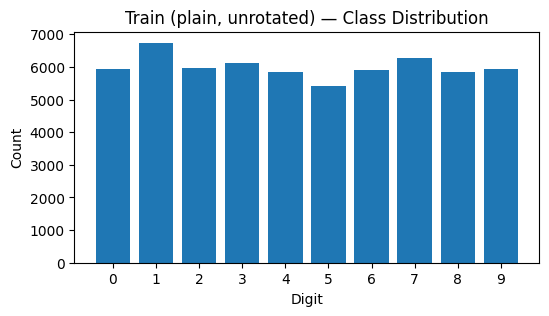

--- Train (C4 augmented) ---
Num samples:     60000
Num batches:     938
Batch shape:     (64, 1, 28, 28)  (B, C, H, W)
Pixel range:     [0.000, 1.000]
Pixel mean/std:  0.1276 / 0.3050
Class counts:    {0: 5923, 1: 6742, 2: 5958, 3: 6131, 4: 5842, 5: 5421, 6: 5918, 7: 6265, 8: 5851, 9: 5949}


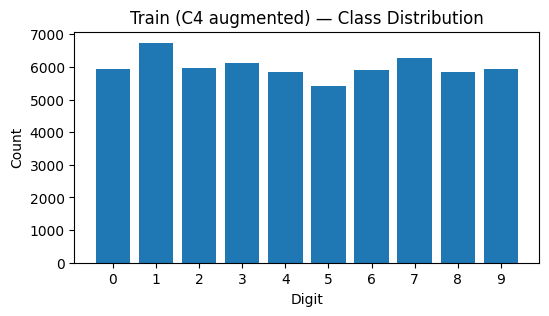

--- Test (original) ---
Num samples:     10000
Num batches:     157
Batch shape:     (64, 1, 28, 28)  (B, C, H, W)
Pixel range:     [0.000, 1.000]
Pixel mean/std:  0.1147 / 0.2892
Class counts:    {0: 980, 1: 1135, 2: 1032, 3: 1010, 4: 982, 5: 892, 6: 958, 7: 1028, 8: 974, 9: 1009}


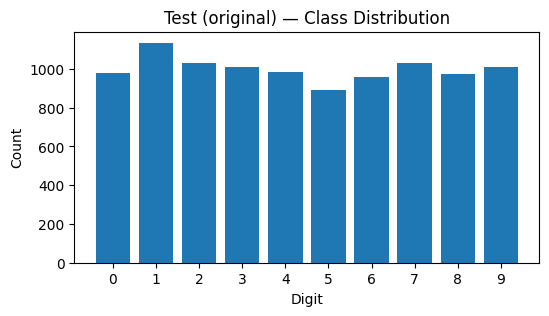

--- Test (fixed rotated) ---
Num samples:     10000
Num batches:     157
Batch shape:     (64, 1, 28, 28)  (B, C, H, W)
Pixel range:     [0.000, 1.000]
Pixel mean/std:  0.1147 / 0.2892
Class counts:    {0: 980, 1: 1135, 2: 1032, 3: 1010, 4: 982, 5: 892, 6: 958, 7: 1028, 8: 974, 9: 1009}


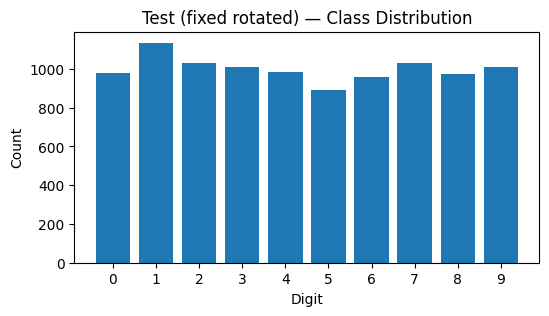

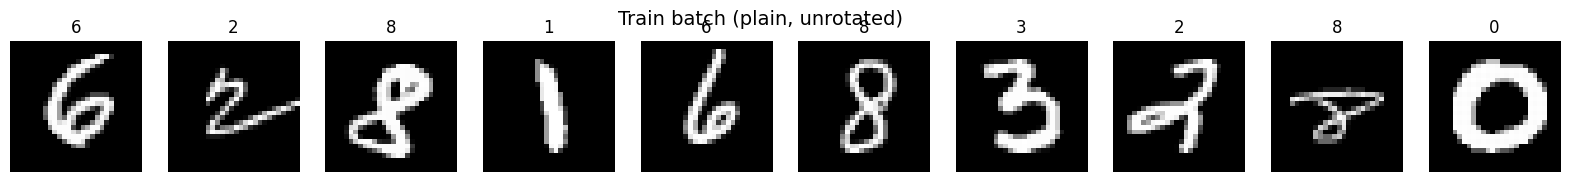

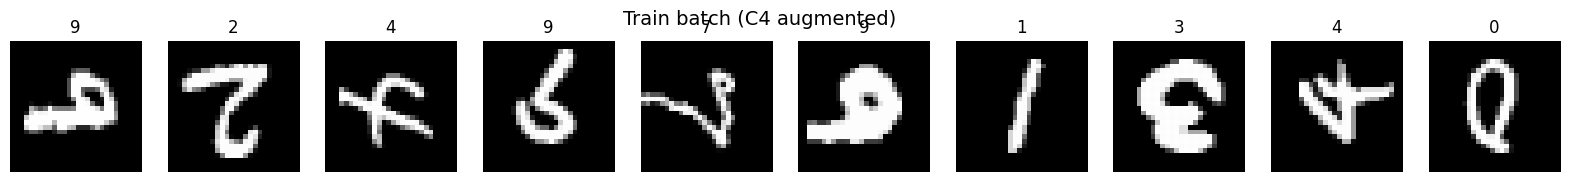

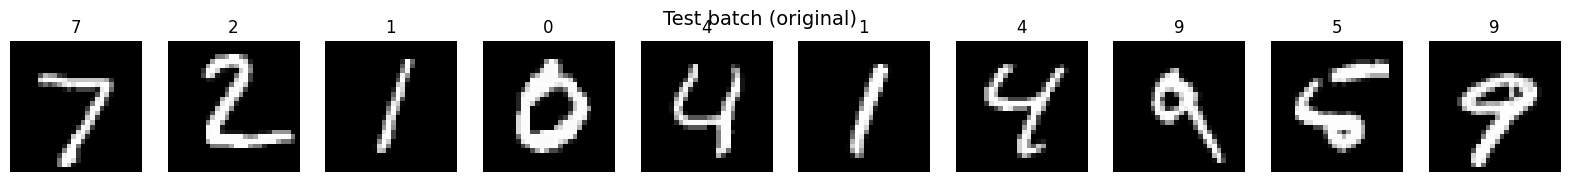

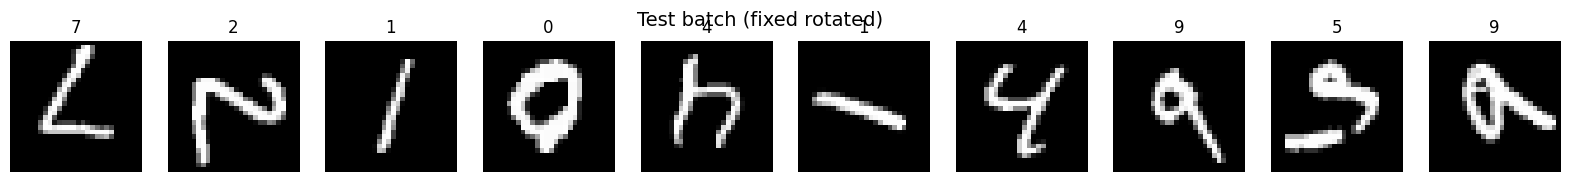

In [9]:
#@title how the data looks

show_dataset_stats(train_loader_plain, name="Train (plain, unrotated)")
show_dataset_stats(train_loader_aug,   name="Train (C4 augmented)")
show_dataset_stats(test_loader_original, name="Test (original)")
show_dataset_stats(test_loader_rotated,  name="Test (fixed rotated)")

show_image_grid(train_loader_plain, n=10, title="Train batch (plain, unrotated)")
show_image_grid(train_loader_aug,   n=10, title="Train batch (C4 augmented)")
show_image_grid(test_loader_original, n=10, title="Test batch (original)")
show_image_grid(test_loader_rotated,  n=10, title="Test batch (fixed rotated)")

### Archeticture

#### Classical CNN for comparison

In [66]:
class StandardCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 28, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(28, 71, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(71, 10)
        )

    def forward(self, x, return_features=False):
        feat = self.features(x)
        if return_features:
            return feat  # [B, 71, 28, 28]
        return self.classifier(feat)

In [67]:
model_cnn = StandardCNN().to(device)
optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
print(f'model size: {sum(p.numel() for p in model_cnn.parameters()):,} parameters')

model size: 18,963 parameters


In [68]:
for epoch in range(1, 6):
    loss = train(model_cnn, train_loader_plain, optimizer_cnn, criterion)
    acc_rot = evaluate(model_cnn, test_loader_rotated)
    acc_orig = evaluate(model_cnn, test_loader_original)
    print(f"[Standard CNN] Epoch {epoch}: Loss={loss:.4f}, Acc(Rotated)={acc_rot:.4f}, Acc(Original)={acc_orig:.4f}")

[Standard CNN] Epoch 1: Loss=1.8545, Acc(Rotated)=0.2327, Acc(Original)=0.3984
[Standard CNN] Epoch 2: Loss=1.4874, Acc(Rotated)=0.2983, Acc(Original)=0.5416
[Standard CNN] Epoch 3: Loss=1.2830, Acc(Rotated)=0.3207, Acc(Original)=0.5865
[Standard CNN] Epoch 4: Loss=1.1286, Acc(Rotated)=0.3435, Acc(Original)=0.6789
[Standard CNN] Epoch 5: Loss=1.0162, Acc(Rotated)=0.3476, Acc(Original)=0.7174


=== Standard CNN Classification Report ===
              precision    recall  f1-score   support

           0     0.3540    0.5306    0.4247       980
           1     0.9498    0.4670    0.6261      1135
           2     0.2491    0.3188    0.2796      1032
           3     0.1839    0.2515    0.2125      1010
           4     0.5450    0.2281    0.3216       982
           5     0.1153    0.2836    0.1640       892
           6     0.2909    0.1743    0.2180       958
           7     0.6908    0.3891    0.4978      1028
           8     0.6064    0.5616    0.5832       974
           9     0.4124    0.2498    0.3111      1009

    accuracy                         0.3476     10000
   macro avg     0.4398    0.3454    0.3639     10000
weighted avg     0.4502    0.3476    0.3695     10000



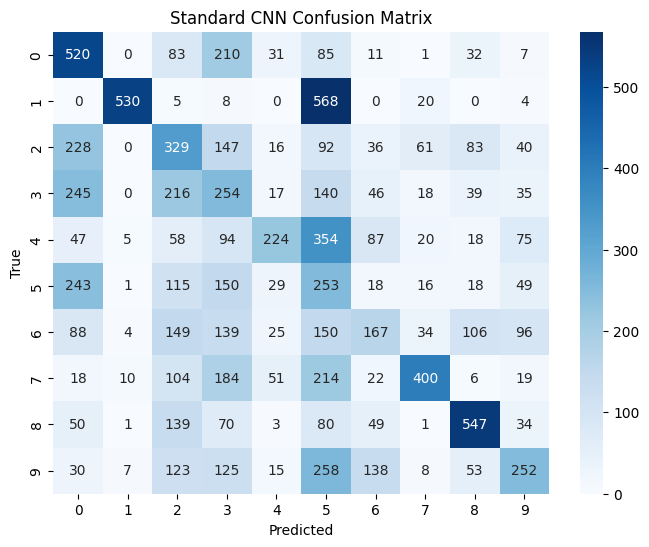

In [69]:
cnn_preds, cnn_labels = get_all_preds(model_cnn, test_loader_rotated)
print("=== Standard CNN Classification Report ===")
print(classification_report(cnn_labels, cnn_preds, digits=4))
plot_confusion_matrix(cnn_labels, cnn_preds, title="Standard CNN Confusion Matrix")

#### Rotation-Augmented-CNN

In [70]:
#@title Standard CNN + rotation augmentation (baseline w/ data aug)

model_cnn_aug = StandardCNN().to(device)
optimizer_cnn_aug = optim.Adam(model_cnn_aug.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
print(f'model size: {sum(p.numel() for p in model_cnn_aug.parameters()):,} parameters')

for epoch in range(1, 6):
    loss = train(model_cnn_aug, train_loader_aug, optimizer_cnn_aug, criterion)
    acc_rot = evaluate(model_cnn_aug, test_loader_rotated)
    acc_orig = evaluate(model_cnn_aug, test_loader_original)
    print(f"[CNN + Aug] Epoch {epoch}: Loss={loss:.4f}, Acc(Rotated)={acc_rot:.4f}, Acc(Original)={acc_orig:.4f}")

model size: 18,963 parameters
[CNN + Aug] Epoch 1: Loss=2.0291, Acc(Rotated)=0.2968, Acc(Original)=0.2923
[CNN + Aug] Epoch 2: Loss=1.8109, Acc(Rotated)=0.3740, Acc(Original)=0.3650
[CNN + Aug] Epoch 3: Loss=1.6822, Acc(Rotated)=0.4205, Acc(Original)=0.4150
[CNN + Aug] Epoch 4: Loss=1.5885, Acc(Rotated)=0.4434, Acc(Original)=0.4476
[CNN + Aug] Epoch 5: Loss=1.5274, Acc(Rotated)=0.4692, Acc(Original)=0.4667


=== CNN + Augmentation Classification Report ===
              precision    recall  f1-score   support

           0     0.4982    0.5786    0.5354       980
           1     0.9268    0.9480    0.9373      1135
           2     0.4091    0.0262    0.0492      1032
           3     0.2671    0.4168    0.3256      1010
           4     0.3725    0.0387    0.0701       982
           5     0.3370    0.3094    0.3226       892
           6     0.3409    0.2046    0.2557       958
           7     0.4369    0.7782    0.5596      1028
           8     0.5931    0.7290    0.6541       974
           9     0.3785    0.5758    0.4568      1009

    accuracy                         0.4692     10000
   macro avg     0.4560    0.4605    0.4166     10000
weighted avg     0.4634    0.4692    0.4243     10000



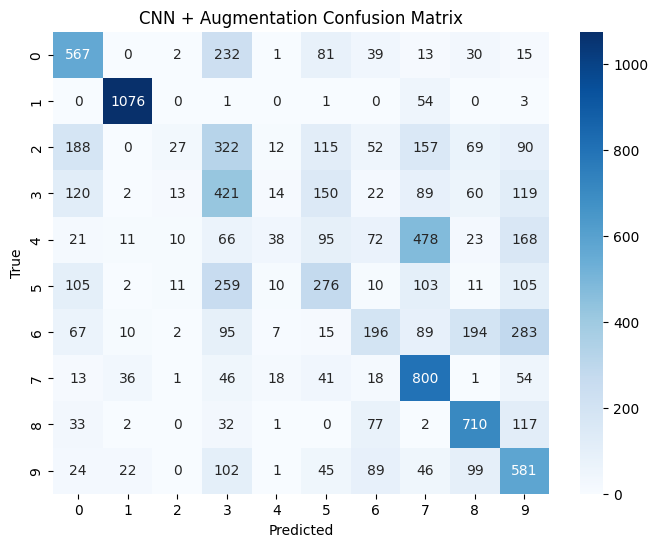

In [71]:
cnn_aug_preds, cnn_aug_labels = get_all_preds(model_cnn_aug, test_loader_rotated)
print("=== CNN + Augmentation Classification Report ===")
print(classification_report(cnn_aug_labels, cnn_aug_preds, digits=4))
plot_confusion_matrix(cnn_aug_labels, cnn_aug_preds, title="CNN + Augmentation Confusion Matrix")

#### G-CNN

In [61]:


def rotate_filter_90s(w, k):
    """
    Rotate kernel tensor w by 90*k degrees counter-clockwise.
    w shape: [C_out, C_in, H, W]
    k: number of 90° rotations (0, 1, 2, 3)
    """
    return torch.rot90(w, k=k, dims=[-2, -1])

class GCNN_C4_Layer(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding=1):
        super().__init__()
        self.kernel_size = kernel_size
        self.in_channels = in_channels
        self.out_channels = out_channels

        # Learnable base kernel
        self.weight = nn.Parameter(
            torch.randn(out_channels, in_channels, kernel_size, kernel_size)
        )
        self.bias = nn.Parameter(torch.zeros(out_channels))

    def forward(self, x):
        # x shape: [B, C_in, H, W]
        outputs = []
        for k in range(4):  # 0°, 90°, 180°, 270°
            w_rot = rotate_filter_90s(self.weight, k)
            out = F.conv2d(x, w_rot, bias=self.bias, padding=self.kernel_size // 2)
            outputs.append(out)
        return torch.stack(outputs, dim=1)  # shape: [B, 4, C_out, H, W]

class GroupPool(nn.Module):
    def forward(self, x):
        # x: [B, G, C, H, W]
        return x.mean(dim=1)  # shape: [B, C, H, W]

class SimpleGCNN_C4(nn.Module):
    def __init__(self):
        super().__init__()
        self.gconv1 = GCNN_C4_Layer(1, 16, kernel_size=3)     # Z2 -> p4, receptive field 3x3
        self.relu1 = nn.ReLU()
        self.gconv2 = GConvC4Layer(16, 32, kernel_size=3)     # p4 -> p4, receptive field ~5x5
        self.relu2 = nn.ReLU()
        self.pool = GroupPool()
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(32, 10)
        )

    def forward(self, x, return_features=False):
        x = self.relu1(self.gconv1(x))   # [B, 4, 16, H, W]
        x = self.relu2(self.gconv2(x))   # [B, 4, 32, H, W]
        if return_features:
            return x
        x = self.pool(x)                 # [B, 32, H, W]
        return self.classifier(x)

In [62]:
x = torch.randn(2, 1, 28, 28)
model_gcnn = SimpleGCNN_C4()
out = model_gcnn(x)
model_gcnn = model_gcnn.to(device)
print(out.shape)
print(f'model size: {sum(p.numel() for p in model_gcnn.parameters()):,} parameters')

torch.Size([2, 10])
model size: 18,954 parameters


### Training

In [63]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
optimizer_gcnn = optim.Adam(model_gcnn.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [64]:
for epoch in range(1, 6):
    loss = train(model_gcnn, train_loader_plain, optimizer_gcnn, criterion)
    acc_rot = evaluate(model_gcnn, test_loader_rotated)
    acc_orig = evaluate(model_gcnn, test_loader_original)
    print(f"[G-CNN] Epoch {epoch}: Loss={loss:.4f}, Acc(Rotated)={acc_rot:.4f}, Acc(Original)={acc_orig:.4f}")

[G-CNN] Epoch 1: Loss=1.9207, Acc(Rotated)=0.3530, Acc(Original)=0.3530
[G-CNN] Epoch 2: Loss=1.6245, Acc(Rotated)=0.4485, Acc(Original)=0.4485
[G-CNN] Epoch 3: Loss=1.4930, Acc(Rotated)=0.4766, Acc(Original)=0.4766
[G-CNN] Epoch 4: Loss=1.4090, Acc(Rotated)=0.5267, Acc(Original)=0.5267
[G-CNN] Epoch 5: Loss=1.3503, Acc(Rotated)=0.5493, Acc(Original)=0.5493


### Eval

=== G-CNN Classification Report ===
              precision    recall  f1-score   support

           0     0.5751    0.7112    0.6359       980
           1     0.9410    0.9700    0.9553      1135
           2     0.4400    0.0107    0.0208      1032
           3     0.4692    0.2713    0.3438      1010
           4     0.5733    0.4542    0.5068       982
           5     0.4070    0.4955    0.4469       892
           6     0.3461    0.4342    0.3852       958
           7     0.6609    0.7014    0.6805      1028
           8     0.6658    0.8326    0.7400       974
           9     0.3513    0.5689    0.4344      1009

    accuracy                         0.5493     10000
   macro avg     0.5430    0.5450    0.5150     10000
weighted avg     0.5499    0.5493    0.5200     10000



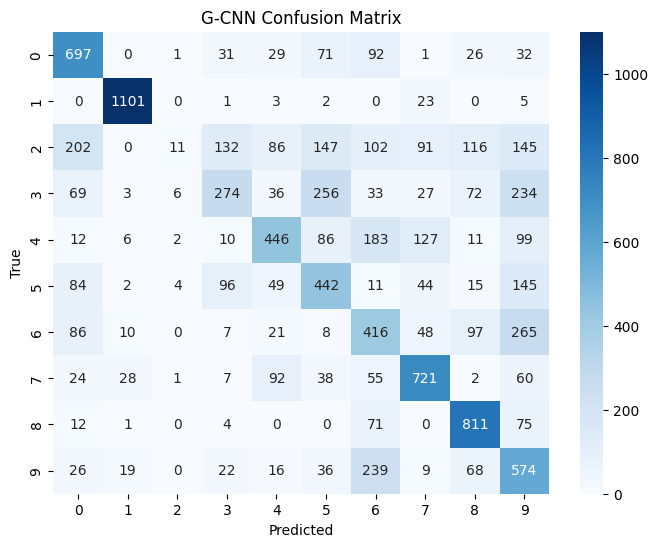

In [65]:
gcnn_preds, gcnn_labels = get_all_preds(model_gcnn, test_loader_rotated)
print("=== G-CNN Classification Report ===")
print(classification_report(gcnn_labels, gcnn_preds, digits=4))
plot_confusion_matrix(gcnn_labels, gcnn_preds, title="G-CNN Confusion Matrix")

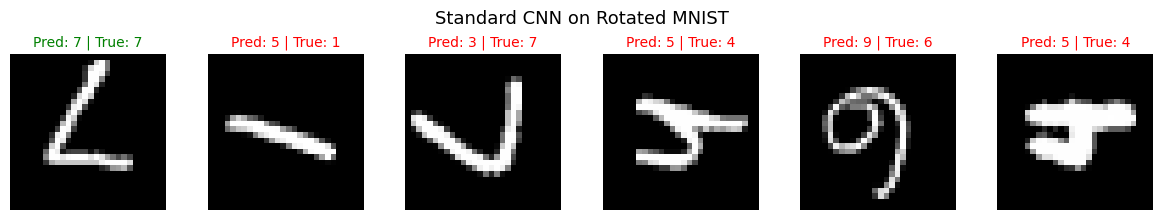

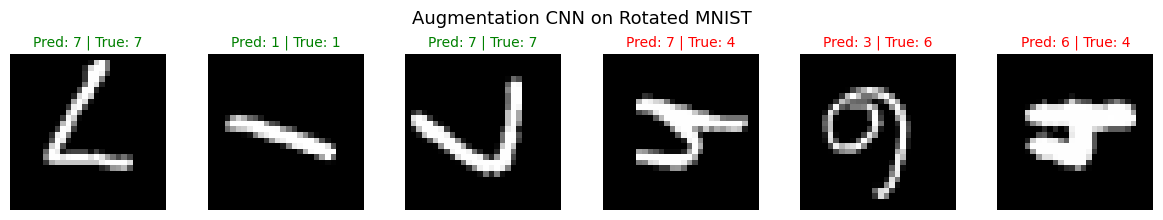

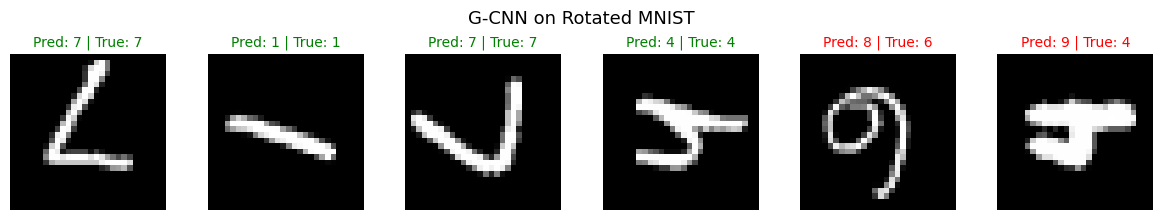

In [99]:
#@title showing preds vs actual in rotation
# G CNN on rotated digits, for comparison
my_indices = [0, 5, 17, 42, 100, 250]

show_predictions(model_cnn, test_loader_rotated.dataset, device, my_indices,
                  title_prefix="Standard CNN on Rotated MNIST")
show_predictions(model_cnn_aug, test_loader_rotated.dataset, device, my_indices,
                  title_prefix="Augmentation CNN on Rotated MNIST")
show_predictions(model_gcnn, test_loader_rotated.dataset, device, my_indices,
                  title_prefix="G-CNN on Rotated MNIST")


## Real-world applications of modified inductive-biases

<img src="https://drive.google.com/uc?id=1u9fF8lZ_ncaGfTgvRW3-n83GQVt1AHQL" width="800"/>

[SE(3) Transformer for 3D point clouds and graphs](https://distill.pub/2020/circuits/equivariance/)


<img src="https://drive.google.com/uc?id=1tx00EmpYgDX_jK5r5DQ4Rw2rrodLzF8-" width="800"/>

[Rotation Equivariant CNNs for Digital Pathology (P4 G-CNNs)](https://arxiv.org/abs/1806.03962)

<img src="https://drive.google.com/uc?id=1Z8UCgyl_1xqBB3YYGqmaWhbzZW8xVVcP" width="800"/>

[Geometry-complete diffusion for 3D molecule generation and optimization](https://www.nature.com/articles/s42004-024-01233-z)